# SHAP Explainability Analysis - Fraud Detection Model

This notebook demonstrates **SHAP (SHapley Additive exPlanations)** analysis for the XGBoost fraud detection model.

## What is SHAP?
SHAP values explain model predictions by attributing the contribution of each feature to the prediction. They answer:
- **Global**: Which features are most important overall?
- **Local**: Why did the model make this specific prediction?

## What You'll Learn:
1. **Feature Importance**: Which features drive fraud predictions?
2. **Individual Explanations**: Why was a transaction flagged as fraud?
3. **Feature Interactions**: How do features interact to influence predictions?
4. **Model Validation**: Verify model behavior aligns with business logic

## Prerequisites:
- Trained fraud detection model in MLflow registry
- Training data available (Athena or CSV)
- MLflow tracking server configured

## 1. Setup and Configuration

In [1]:
# Install project in editable mode
! uv pip install -e ../

Using Python 3.13.5 environment at: /Users/skoppar/workspace/sample-mlops-bestpractices/.venv
⠹ onnx==1.21.0                                                                  Resolved 216 packages in 249ms
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
   Building sagemaker-automated-drift-and-trend-monitoring @ file:///Users/skopp
      Built sagemaker-automated-drift-and-trend-monitoring @ file:

In [2]:
import sys
print(f"Python: {sys.executable}")

# Verify SHAP is installed
import shap
print(f"SHAP version: {shap.__version__}")

Python: /Users/skoppar/workspace/sample-mlops-bestpractices/.venv/bin/python


/Users/skoppar/workspace/sample-mlops-bestpractices/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [3]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML imports
import mlflow
import xgboost as xgb
import shap

# Setup Python path
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if 'notebooks' in str(notebook_dir) else notebook_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Load environment variables
from dotenv import load_dotenv
env_path = project_root / '.env'
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"✓ Loaded environment from: {env_path}")
else:
    print(f"⚠ .env file not found at: {env_path}")

# Project imports
from src.config.config import (
    MLFLOW_TRACKING_URI,
    MLFLOW_EXPERIMENT_NAME,
    MLFLOW_MODEL_NAME,
    MLFLOW_MONITORING_EXPERIMENT_NAME,
    AWS_DEFAULT_REGION,
    TRAINING_FEATURES
)
from src.utils.shap_utils import (
    load_model_from_mlflow,
    prepare_background_data,
    compute_shap_values,
    validate_shap_values,
    create_shap_visualizations,
    save_shap_artifacts_to_mlflow
)
from src.utils.mlflow_utils import setup_mlflow_tracking

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

print("✓ All imports successful")

✓ Loaded environment from: /Users/skoppar/workspace/sample-mlops-bestpractices/sagemaker-automated-drift-and-trend-monitoring/.env
✓ All imports successful


In [4]:
# Initialize MLflow
setup_mlflow_tracking(MLFLOW_TRACKING_URI)

print("MLflow Configuration:")
print(f"  Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"  Training Experiment: {MLFLOW_EXPERIMENT_NAME}")
print(f"  Monitoring Experiment: {MLFLOW_MONITORING_EXPERIMENT_NAME}")
print(f"  Model Registry: {MLFLOW_MODEL_NAME}")
print(f"  Region: {AWS_DEFAULT_REGION}")

MLflow tracking URI set to: arn:aws:sagemaker:us-east-1:<ACCOUNT_ID>:mlflow-app/app-VG5VVXAMF5GQ
MLflow Configuration:
  Tracking URI: arn:aws:sagemaker:us-east-1:<ACCOUNT_ID>:mlflow-app/app-VG5VVXAMF5GQ
  Training Experiment: credit-card-fraud-detection-training
  Monitoring Experiment: credit-card-fraud-detection-monitoring
  Model Registry: xgboost-fraud-detector
  Region: us-east-1


## 2. Load Model from MLflow

We'll load the latest registered model from MLflow. You can also specify a specific run ID.

In [5]:
# Get latest registered model
client = mlflow.tracking.MlflowClient()

try:
    # Get latest version of registered model
    latest_versions = client.get_latest_versions(MLFLOW_MODEL_NAME, stages=["None", "Production", "Staging"])
    
    if not latest_versions:
        print(f"⚠ No registered versions found for model: {MLFLOW_MODEL_NAME}")
        print("Please train a model first using notebook 1_training_pipeline.ipynb")
        MODEL_RUN_ID = None
    else:
        # Get the latest version
        latest_version = sorted(latest_versions, key=lambda x: int(x.version), reverse=True)[0]
        MODEL_RUN_ID = latest_version.run_id
        
        print(f"Latest Registered Model:")
        print(f"  Name: {latest_version.name}")
        print(f"  Version: {latest_version.version}")
        print(f"  Stage: {latest_version.current_stage}")
        print(f"  Run ID: {MODEL_RUN_ID}")
        print(f"  Status: {latest_version.status}")
        
except Exception as e:
    print(f"Error getting registered model: {e}")
    print("\nAlternative: Specify a run ID manually below")
    MODEL_RUN_ID = None

Latest Registered Model:
  Name: xgboost-fraud-detector
  Version: 24
  Stage: Staging
  Run ID: 09d5a27b4a3d4468ad2c17a9f3b9bae4
  Status: READY


In [6]:
# Optional: Override with specific run ID
#MODEL_RUN_ID = "bbb5436e9bcb47e6ad7f4824f5df0c21"

if MODEL_RUN_ID:
    print(f"Loading model from run: {MODEL_RUN_ID}")
    model, feature_names = load_model_from_mlflow(MODEL_RUN_ID)
    
    print(f"\n✓ Model loaded successfully")
    print(f"  Type: {type(model).__name__}")
    print(f"  Features: {len(feature_names)}")
    print(f"\nFeature Names:")
    for i, feat in enumerate(feature_names, 1):
        print(f"  {i:2d}. {feat}")
else:
    print("⚠ No model loaded. Please set MODEL_RUN_ID above.")

Loading model from run: 09d5a27b4a3d4468ad2c17a9f3b9bae4



✓ Model loaded successfully
  Type: Booster
  Features: 30

Feature Names:
   1. transaction_hour
   2. transaction_day_of_week
   3. transaction_amount
   4. transaction_type_code
   5. customer_age
   6. customer_gender
   7. customer_tenure_months
   8. account_age_days
   9. distance_from_home_km
  10. distance_from_last_transaction_km
  11. time_since_last_transaction_min
  12. online_transaction
  13. international_transaction
  14. high_risk_country
  15. merchant_category_code
  16. merchant_reputation_score
  17. chip_transaction
  18. pin_used
  19. card_present
  20. cvv_match
  21. address_verification_match
  22. num_transactions_24h
  23. num_transactions_7days
  24. avg_transaction_amount_30days
  25. max_transaction_amount_30days
  26. velocity_score
  27. recurring_transaction
  28. previous_fraud_incidents
  29. credit_limit
  30. available_credit_ratio


## 3. Load Training Data

Load data from Athena or CSV for SHAP analysis.

In [7]:
# Configuration
DATA_SOURCE = "csv"  # "csv" or "athena"
NUM_SAMPLES = 5000   # Total samples to load

if DATA_SOURCE == "athena":
    from src.train_pipeline.athena.athena_client import AthenaClient
    from src.config.config import ATHENA_TRAINING_TABLE
    
    print(f"Loading {NUM_SAMPLES} samples from Athena...")
    athena_client = AthenaClient()
    df = athena_client.read_table(ATHENA_TRAINING_TABLE, limit=NUM_SAMPLES)
    print(f"✓ Loaded {len(df)} rows from Athena")
else:
    from src.config.config import CSV_TRAINING_DATA
    
    print(f"Loading from CSV: {CSV_TRAINING_DATA}")
    df = pd.read_csv(CSV_TRAINING_DATA)
    
    # Sample if dataset is large
    if len(df) > NUM_SAMPLES:
        df = df.sample(n=NUM_SAMPLES, random_state=42)
    
    print(f"✓ Loaded {len(df)} rows from CSV")

# Display basic info
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

# Check for target column
from src.config.config import TARGET_COLUMN
if TARGET_COLUMN in df.columns:
    fraud_rate = df[TARGET_COLUMN].mean()
    print(f"\nFraud Rate: {fraud_rate:.2%}")
    print(f"  Fraud cases: {df[TARGET_COLUMN].sum()}")
    print(f"  Non-fraud cases: {(~df[TARGET_COLUMN].astype(bool)).sum()}")
else:
    print(f"⚠ Target column '{TARGET_COLUMN}' not found")

Loading from CSV: /Users/skoppar/workspace/sample-mlops-bestpractices/sagemaker-automated-drift-and-trend-monitoring/data/creditcard_predictions_final.csv
✓ Loaded 5000 rows from CSV

Dataset Shape: (5000, 35)
Columns: 35

Fraud Rate: 0.12%
  Fraud cases: 6
  Non-fraud cases: 4994


In [8]:
# Prepare features and target

# First, check if we need to one-hot encode customer_gender
if 'customer_gender' in df.columns and 'customer_gender_Male' in feature_names:
    print("⚠ Found categorical feature 'customer_gender' - applying one-hot encoding...")
    # One-hot encode categorical features (same as training)
    df_encoded = pd.get_dummies(df, columns=['customer_gender'], drop_first=True)
    print(f"  ✓ One-hot encoded: {[c for c in df_encoded.columns if 'customer_gender_' in c]}")
    
    # Now select features
    X = df_encoded[feature_names].copy()
    y = df_encoded[TARGET_COLUMN].copy() if TARGET_COLUMN in df_encoded.columns else None
else:
    # No encoding needed
    X = df[feature_names].copy()
    y = df[TARGET_COLUMN].copy() if TARGET_COLUMN in df.columns else None

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape if y is not None else 'N/A'}")

# Verify all features are numeric
print(f"\nFeature dtypes:")
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"  ✗ WARNING: Non-numeric features found: {non_numeric}")
    print(f"  These will cause errors in SHAP. Please encode them.")
else:
    print(f"  ✓ All features are numeric")

# Check for missing values
missing = X.isnull().sum().sum()
if missing > 0:
    print(f"\n⚠ Found {missing} missing values")
    print("\nMissing values by feature:")
    print(X.isnull().sum()[X.isnull().sum() > 0])
else:
    print("\n✓ No missing values")

Features shape: (5000, 30)
Target shape: (5000,)

Feature dtypes:
  ✗ WARNING: Non-numeric features found: ['customer_gender']
  These will cause errors in SHAP. Please encode them.

✓ No missing values


## 4. Prepare Background Dataset

SHAP requires a background dataset to estimate the expected value (baseline prediction). We use stratified sampling to maintain the fraud/non-fraud ratio.

In [9]:
# Configuration
BACKGROUND_SAMPLES = 500
EXPLAIN_SAMPLES = 200  # Number of predictions to explain

# Prepare background data (stratified sampling)
print(f"Preparing background dataset ({BACKGROUND_SAMPLES} samples)...")
X_background = prepare_background_data(
    X, y,
    n_samples=BACKGROUND_SAMPLES,
    stratify=True if y is not None else False,
    random_state=42
)

# Prepare data to explain
print(f"\nPreparing explanation dataset ({EXPLAIN_SAMPLES} samples)...")
if len(X) > EXPLAIN_SAMPLES:
    # Sample diverse predictions (stratified)
    if y is not None:
        from sklearn.model_selection import train_test_split
        _, X_explain, _, y_explain = train_test_split(
            X, y, test_size=EXPLAIN_SAMPLES, stratify=y, random_state=42
        )
    else:
        X_explain = X.sample(n=EXPLAIN_SAMPLES, random_state=42)
        y_explain = None
else:
    X_explain = X
    y_explain = y

print(f"✓ Background data: {X_background.shape}")
print(f"✓ Explanation data: {X_explain.shape}")

if y_explain is not None:
    print(f"\nExplanation Set Fraud Rate: {y_explain.mean():.2%}")

Preparing background dataset (500 samples)...

Preparing explanation dataset (200 samples)...
✓ Background data: (500, 30)
✓ Explanation data: (200, 30)

Explanation Set Fraud Rate: 0.00%


## 5. Compute SHAP Values

We use TreeExplainer, which is optimized for XGBoost and provides exact Shapley values.

In [10]:
import time

print("Computing SHAP values...\n")
print("This may take a few minutes depending on:")
print(f"  - Background samples: {len(X_background)}")
print(f"  - Explanation samples: {len(X_explain)}")
print(f"  - Features: {len(feature_names)}")
print("\nProgress: Starting...")

start_time = time.time()

# Compute SHAP values
explainer, shap_values = compute_shap_values(
    model,
    X_background,
    X_explain,
    check_additivity=False  # Set True for debugging, but slower
)

elapsed_time = time.time() - start_time

print(f"\n✓ SHAP computation complete!")
print(f"  Time: {elapsed_time:.2f} seconds")
print(f"  Rate: {len(X_explain) / elapsed_time:.1f} samples/second")
print(f"  SHAP values shape: {shap_values.shape}")
print(f"  Expected value (base): {explainer.expected_value}")

Converting non-numeric column 'customer_gender' to float64
Converting non-numeric column 'customer_gender' to float64


Computing SHAP values...

This may take a few minutes depending on:
  - Background samples: 500
  - Explanation samples: 200
  - Features: 30

Progress: Starting...

✓ SHAP computation complete!
  Time: 0.24 seconds
  Rate: 824.5 samples/second
  SHAP values shape: (200, 30)
  Expected value (base): -9.153280545960879


## 6. Validate SHAP Values

Verify the mathematical consistency: `base_value + sum(shap_values) ≈ model_prediction`

In [11]:
# Get model predictions

# Ensure X_explain is numeric for XGBoost
X_explain_numeric = X_explain.copy()
for col in X_explain_numeric.columns:
    if X_explain_numeric[col].dtype == 'object' or X_explain_numeric[col].dtype.name == 'category':
        X_explain_numeric[col] = pd.to_numeric(X_explain_numeric[col], errors='coerce')
X_explain_numeric = X_explain_numeric.astype(np.float64)

if isinstance(model, xgb.Booster):
    dmatrix = xgb.DMatrix(X_explain_numeric)
    predictions = model.predict(dmatrix)
else:
    predictions = model.predict_proba(X_explain_numeric)[:, 1]  # Fraud probability

print(f"Model Predictions:")
print(f"  Min: {predictions.min():.4f}")
print(f"  Max: {predictions.max():.4f}")
print(f"  Mean: {predictions.mean():.4f}")
print(f"  Median: {np.median(predictions):.4f}")

# Validate SHAP values
print("\nValidating SHAP values...")
validation_results = validate_shap_values(
    explainer,
    shap_values,
    predictions,
    tolerance=1e-4
)

if validation_results['passed']:
    print(f"\n✓ SHAP Validation PASSED")
    print(f"  Max error: {validation_results['max_error']:.2e}")
    print(f"  Mean error: {validation_results['mean_error']:.2e}")
else:
    print(f"\n✗ SHAP Validation FAILED")
    print(f"  Failed samples: {len(validation_results['failed_samples'])}")
    print(f"  Max error: {validation_results['max_error']:.2e}")
    print(f"\nFirst few failures:")
    for sample in validation_results['failed_samples'][:3]:
        print(f"  Sample {sample['index']}: error = {sample['error']:.2e}")

Model Predictions:
  Min: 0.0000
  Max: 0.0083
  Mean: 0.0002
  Median: 0.0001

Validating SHAP values...

✓ SHAP Validation PASSED
  Max error: 3.20e-08
  Mean error: 4.38e-10


## 7. Global Interpretability: Feature Importance

Which features are most important overall?

Top 10 Features by SHAP Importance:

                  feature  importance
         account_age_days    0.364569
     num_transactions_24h    0.294112
       online_transaction    0.248385
         transaction_hour    0.226973
    recurring_transaction    0.164914
international_transaction    0.104973
             customer_age    0.103817
       transaction_amount    0.082650
                 pin_used    0.081769
             credit_limit    0.081251


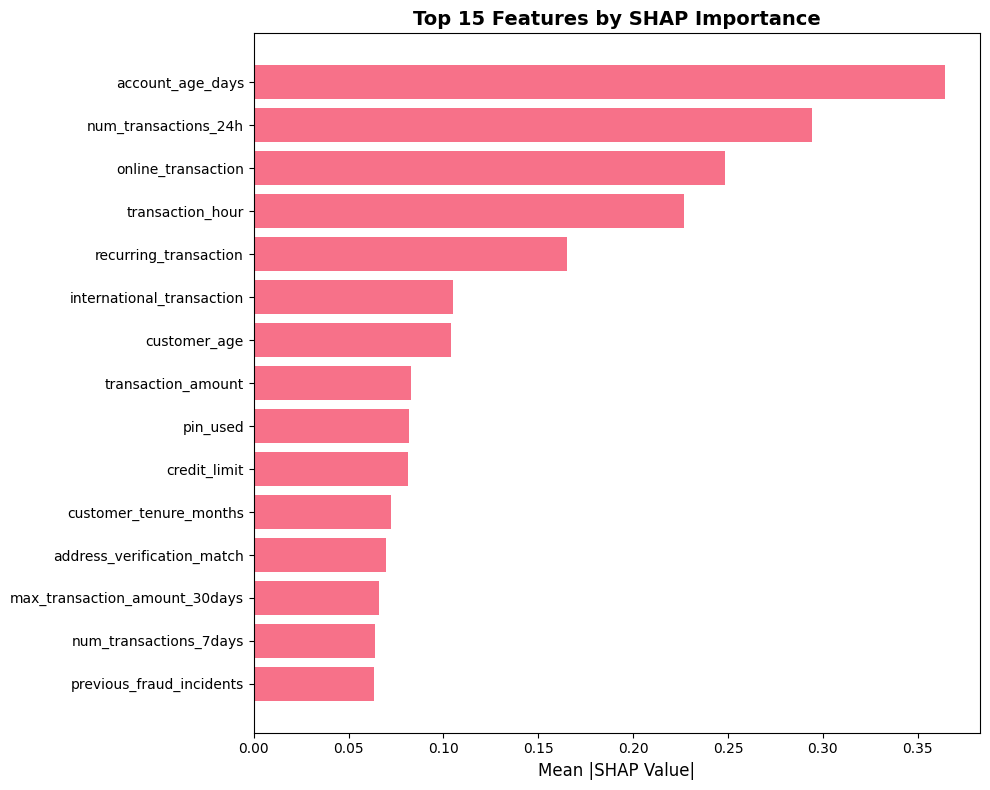


💡 Insight: The top feature 'account_age_days' has 0.3646 mean absolute SHAP value.


In [12]:
# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print("Top 10 Features by SHAP Importance:\n")
print(feature_importance_df.head(10).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Mean |SHAP Value|', fontsize=12)
plt.title('Top 15 Features by SHAP Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 Insight: The top feature '{top_features.iloc[0]['feature']}' has {top_features.iloc[0]['importance']:.4f} mean absolute SHAP value.")

## 8. SHAP Summary Plots

**Bar plot**: Shows feature importance (mean absolute SHAP)

**Beeswarm plot**: Shows feature value distribution and impact on predictions

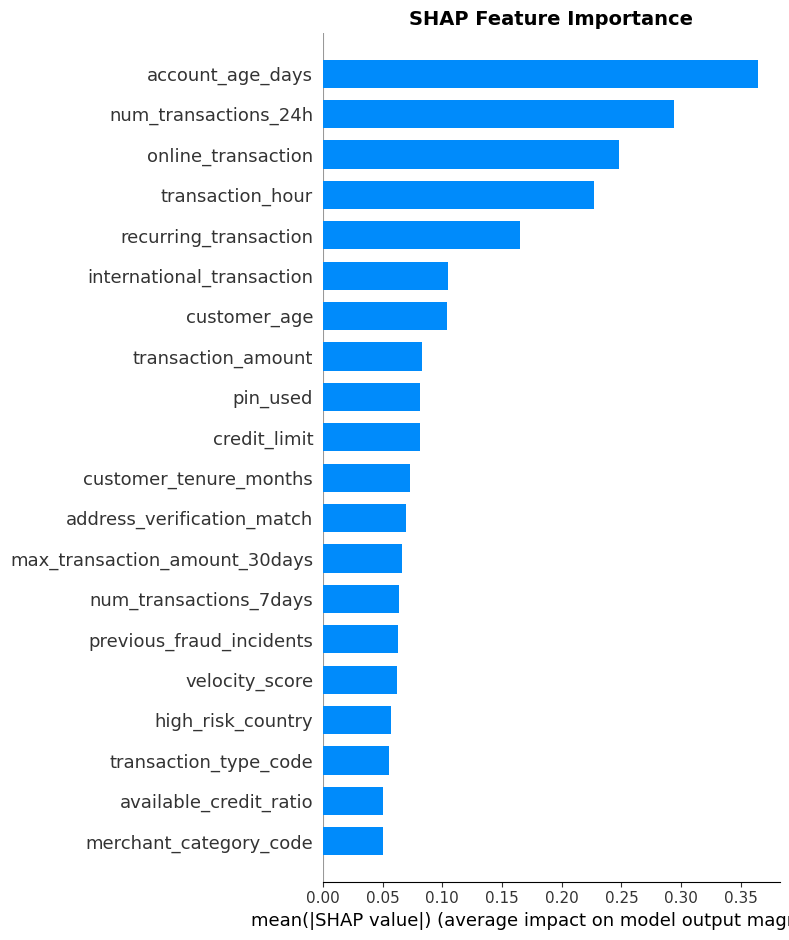


📊 Interpretation: Features are ranked by their average impact on model output magnitude.


In [13]:
# Summary plot (bar) - Feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_explain, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation: Features are ranked by their average impact on model output magnitude.")

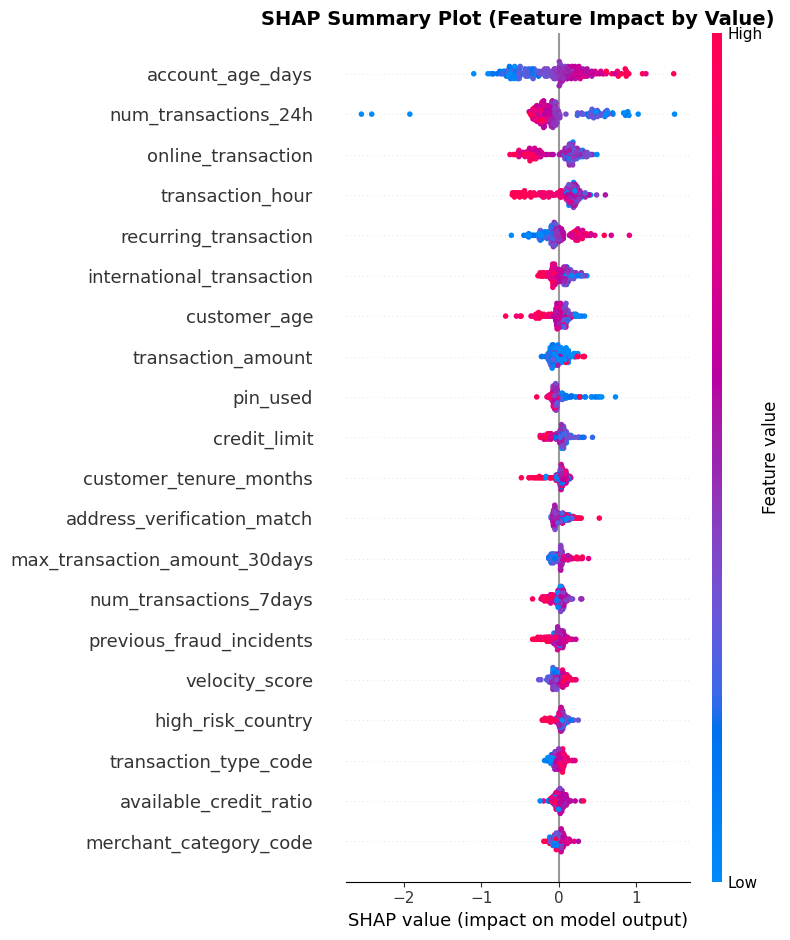


📊 Interpretation:
  - Each dot is a sample
  - X-axis: SHAP value (left = decreases fraud prob, right = increases fraud prob)
  - Color: Feature value (pink = high, blue = low)
  - Vertical spread: Number of samples with that SHAP value


In [14]:
# Summary plot (beeswarm) - Feature value impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_explain, max_display=20, show=False)
plt.title("SHAP Summary Plot (Feature Impact by Value)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  - Each dot is a sample")
print("  - X-axis: SHAP value (left = decreases fraud prob, right = increases fraud prob)")
print("  - Color: Feature value (pink = high, blue = low)")
print("  - Vertical spread: Number of samples with that SHAP value")

## 9. Local Interpretability: Individual Predictions

### 9.1 Waterfall Plot - Fraud Case

Analyzing Fraud Case:
  Sample index: 198
  Fraud probability: 0.0083
  Actual label: Non-Fraud


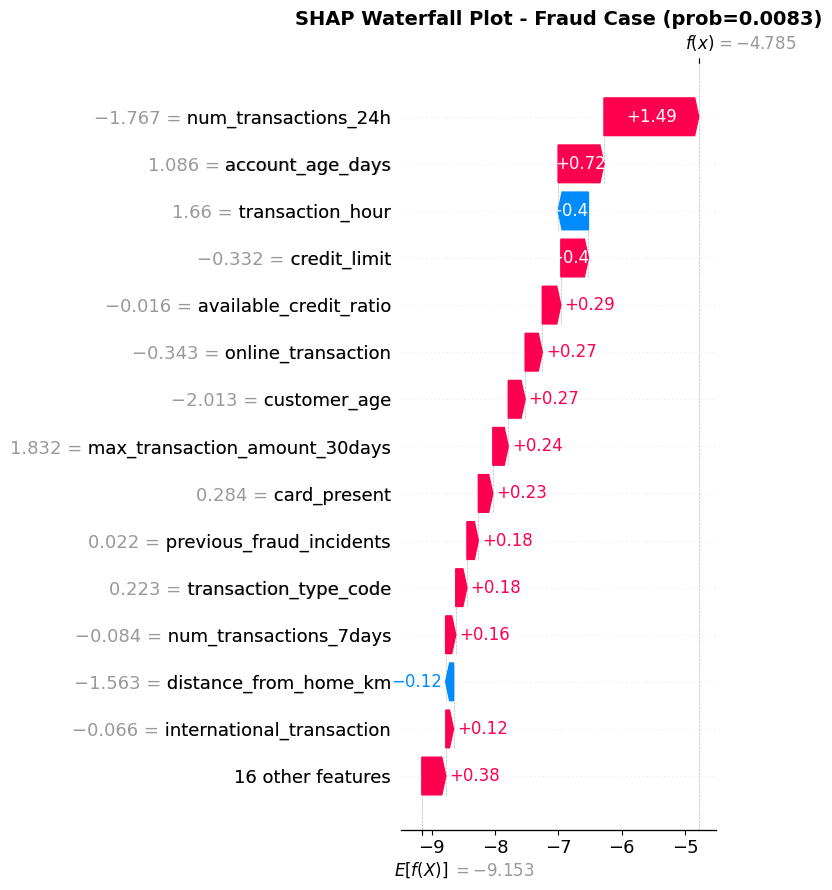


📊 Interpretation:
  - Base value (E[f(x)]): Expected fraud probability
  - Red bars: Features pushing prediction HIGHER (toward fraud)
  - Blue bars: Features pushing prediction LOWER (toward non-fraud)
  - Final prediction: Base value + sum of all feature contributions


In [15]:
# Find a fraud case (highest fraud probability)
fraud_idx = np.argmax(predictions)
fraud_prob = predictions[fraud_idx]

print(f"Analyzing Fraud Case:")
print(f"  Sample index: {fraud_idx}")
print(f"  Fraud probability: {fraud_prob:.4f}")
if y_explain is not None:
    actual_label = "Fraud" if y_explain.iloc[fraud_idx] else "Non-Fraud"
    print(f"  Actual label: {actual_label}")

# Waterfall plot
plt.figure(figsize=(10, 8))
base_val = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1]
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=base_val,
        data=X_explain.iloc[fraud_idx],
        feature_names=list(X_explain.columns)
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall Plot - Fraud Case (prob={fraud_prob:.4f})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  - Base value (E[f(x)]): Expected fraud probability")
print("  - Red bars: Features pushing prediction HIGHER (toward fraud)")
print("  - Blue bars: Features pushing prediction LOWER (toward non-fraud)")
print("  - Final prediction: Base value + sum of all feature contributions")

### 9.2 Waterfall Plot - Non-Fraud Case

Analyzing Non-Fraud Case:
  Sample index: 38
  Fraud probability: 0.0000
  Actual label: Non-Fraud


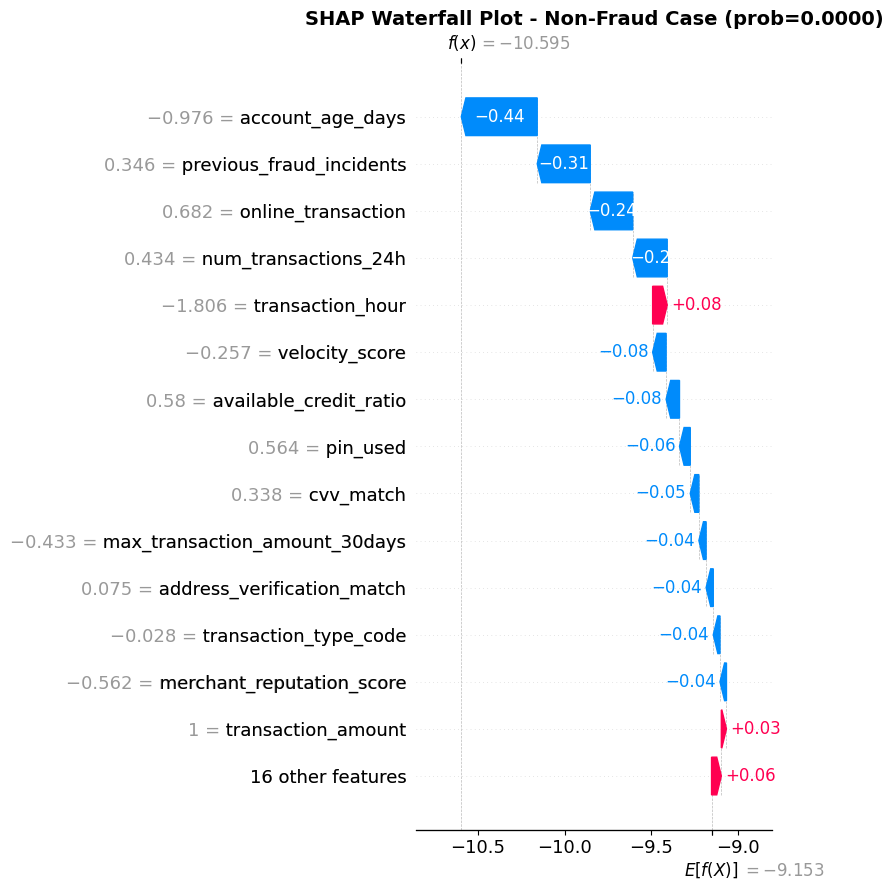


💡 Insight: Compare this to the fraud case above to see how feature contributions differ.


In [16]:
# Find a non-fraud case (lowest fraud probability)
non_fraud_idx = np.argmin(predictions)
non_fraud_prob = predictions[non_fraud_idx]

print(f"Analyzing Non-Fraud Case:")
print(f"  Sample index: {non_fraud_idx}")
print(f"  Fraud probability: {non_fraud_prob:.4f}")
if y_explain is not None:
    actual_label = "Fraud" if y_explain.iloc[non_fraud_idx] else "Non-Fraud"
    print(f"  Actual label: {actual_label}")

# Waterfall plot
plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[non_fraud_idx],
        base_values=base_val,
        data=X_explain.iloc[non_fraud_idx],
        feature_names=list(X_explain.columns)
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall Plot - Non-Fraud Case (prob={non_fraud_prob:.4f})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Compare this to the fraud case above to see how feature contributions differ.")

### 9.3 Force Plot (Interactive)

In [17]:
# Force plot for a single prediction (interactive HTML)
sample_idx = fraud_idx  # Use fraud case from above

print(f"Creating force plot for sample {sample_idx}...")
shap.initjs()
force_plot = shap.force_plot(
    base_val,
    shap_values[sample_idx],
    X_explain.iloc[sample_idx],
    matplotlib=False
)

display(force_plot)

print("\n📊 Interactive force plot displayed above.")
print("  - Hover over features to see their names and values")
print("  - Red: Features increasing fraud probability")
print("  - Blue: Features decreasing fraud probability")

Creating force plot for sample 198...



📊 Interactive force plot displayed above.
  - Hover over features to see their names and values
  - Red: Features increasing fraud probability
  - Blue: Features decreasing fraud probability


### 9.4 Decision Plot (Compare Multiple Predictions)

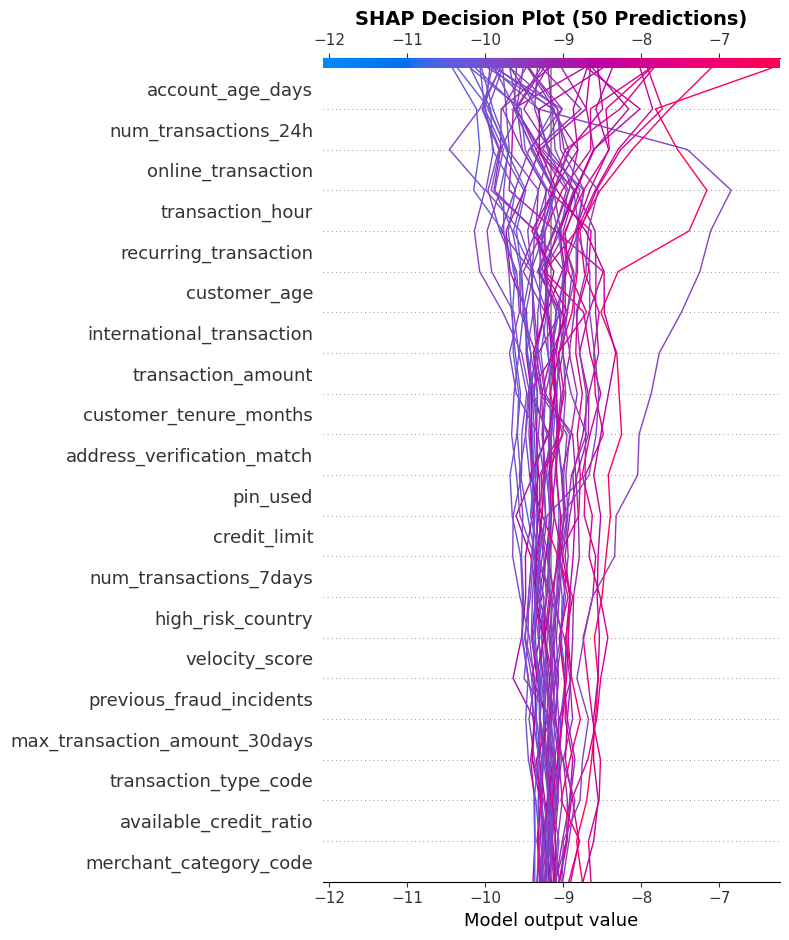


📊 Interpretation:
  - Each line represents one prediction
  - Y-axis: Features (ordered by importance)
  - X-axis: Model output (fraud probability)
  - Lines moving right: Features increasing fraud probability
  - Lines moving left: Features decreasing fraud probability


In [18]:
# Decision plot - compare multiple predictions
sample_size = min(50, len(X_explain))
sample_indices = np.random.choice(len(X_explain), size=sample_size, replace=False)

plt.figure(figsize=(12, 8))
shap.decision_plot(
    base_val,
    shap_values[sample_indices],
    X_explain.iloc[sample_indices],
    show=False
)
plt.title(f"SHAP Decision Plot ({sample_size} Predictions)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  - Each line represents one prediction")
print("  - Y-axis: Features (ordered by importance)")
print("  - X-axis: Model output (fraud probability)")
print("  - Lines moving right: Features increasing fraud probability")
print("  - Lines moving left: Features decreasing fraud probability")

## 10. Feature Interactions: Dependence Plots

Dependence plots show how a feature's value affects its SHAP value, revealing interactions with other features.

Creating dependence plots for top 3 features:
  1. account_age_days
  2. num_transactions_24h
  3. online_transaction


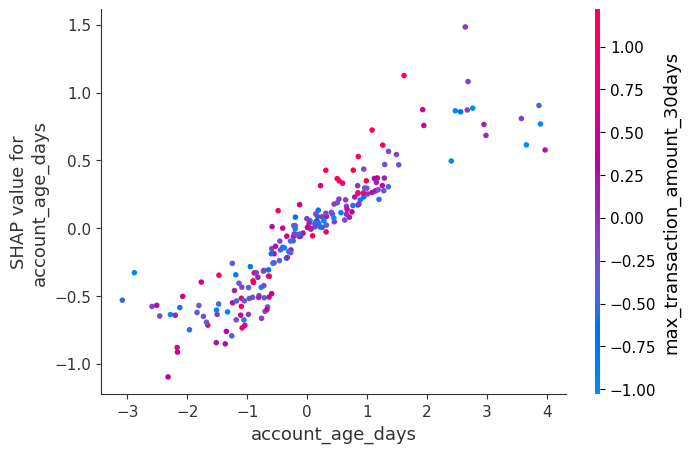

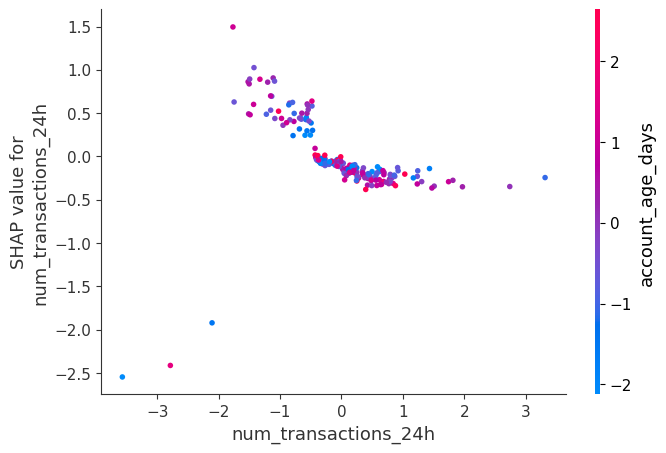

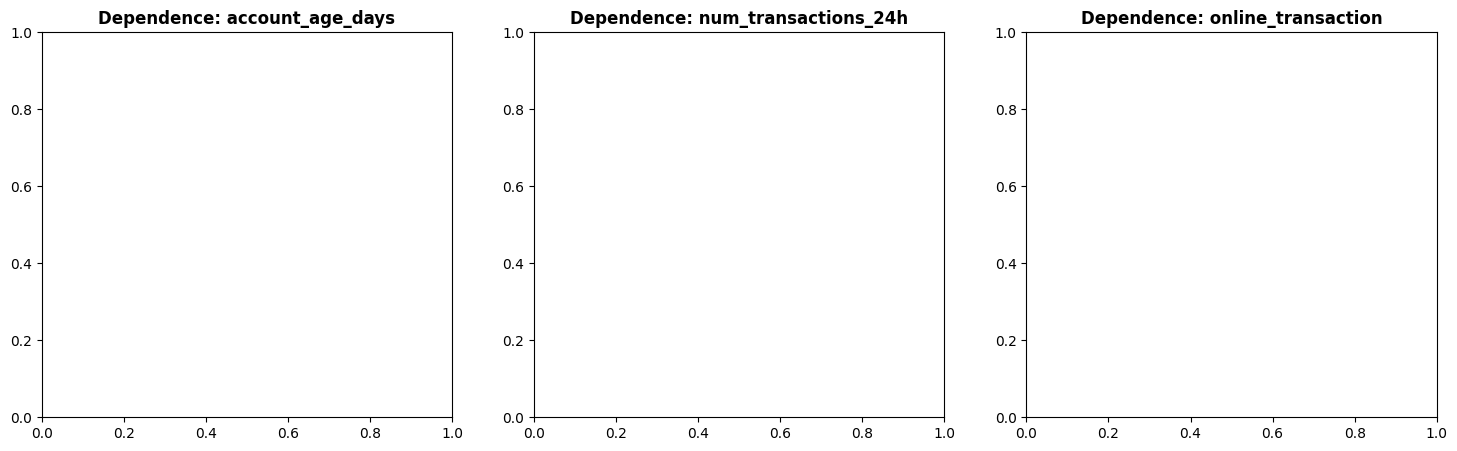

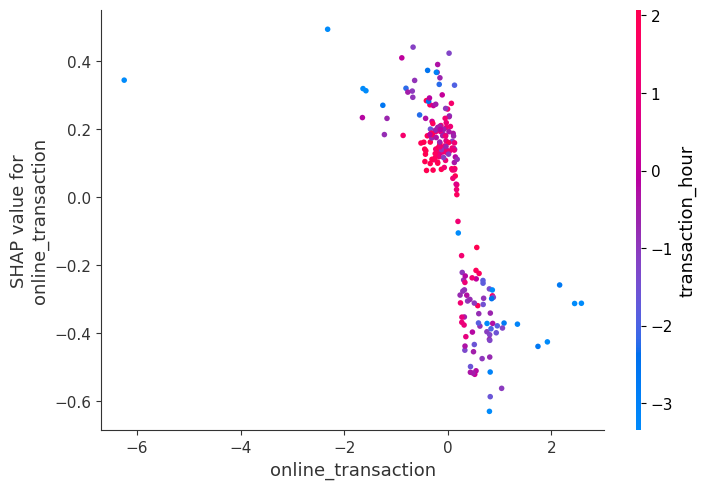


📊 Interpretation:
  - X-axis: Feature value
  - Y-axis: SHAP value (impact on prediction)
  - Color: Another feature (automatic interaction detection)
  - Vertical scatter at same X: Interactions with other features


In [19]:
# Get top 3 features
top_3_features = feature_importance_df.head(3)['feature'].tolist()

print(f"Creating dependence plots for top 3 features:")
for rank, feature in enumerate(top_3_features, 1):
    print(f"  {rank}. {feature}")

# Create dependence plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_3_features):
    feat_idx = feature_names.index(feature)
    
    plt.sca(axes[idx])
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_explain,
        show=False
    )
    axes[idx].set_title(f"Dependence: {feature}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  - X-axis: Feature value")
print("  - Y-axis: SHAP value (impact on prediction)")
print("  - Color: Another feature (automatic interaction detection)")
print("  - Vertical scatter at same X: Interactions with other features")

## 11. Save Artifacts

Save all plots and log to MLflow.

In [20]:
# Create output directory
output_dir = Path("shap_output")
output_dir.mkdir(exist_ok=True)

print(f"Saving SHAP artifacts to: {output_dir}")

# Generate all visualizations
plot_paths = create_shap_visualizations(
    explainer,
    shap_values,
    X_explain,
    output_dir,
    max_display=20
)

print(f"\n✓ Saved {len(plot_paths)} visualizations:")
for plot_name, plot_path in plot_paths.items():
    print(f"  - {plot_path}")

Saving SHAP artifacts to: shap_output

✓ Saved 9 visualizations:
  - shap_output/shap_summary_bar.png
  - shap_output/shap_summary_beeswarm.png
  - shap_output/shap_waterfall_fraud.png
  - shap_output/shap_waterfall_non_fraud.png
  - shap_output/shap_force_plot.html
  - shap_output/shap_decision_plot.png
  - shap_output/shap_dependence_1_account_age_days.png
  - shap_output/shap_dependence_2_num_transactions_24h.png
  - shap_output/shap_dependence_3_online_transaction.png


In [21]:
# Save SHAP values as CSV
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_csv_path = output_dir / "shap_values.csv"
shap_df.to_csv(shap_csv_path, index=False)
print(f"✓ Saved SHAP values: {shap_csv_path}")

# Save feature importance
feature_importance_df.to_csv(output_dir / "feature_importance.csv", index=False)
print(f"✓ Saved feature importance: {output_dir / 'feature_importance.csv'}")

✓ Saved SHAP values: shap_output/shap_values.csv
✓ Saved feature importance: shap_output/feature_importance.csv


## 12. Log to MLflow

Log all SHAP artifacts to MLflow for tracking and comparison.

In [22]:
print("Logging SHAP artifacts to MLflow...")

shap_run_id = save_shap_artifacts_to_mlflow(
    training_run_id=MODEL_RUN_ID,
    shap_values=shap_values,
    plot_paths=plot_paths,
    feature_names=feature_names,
    experiment_name=MLFLOW_MONITORING_EXPERIMENT_NAME
)

print(f"\n✓ SHAP artifacts logged to MLflow")
print(f"  Run ID: {shap_run_id}")
print(f"  Experiment: {MLFLOW_MONITORING_EXPERIMENT_NAME}")
print(f"  Training Run: {MODEL_RUN_ID}")

# Construct MLflow UI URL
mlflow_browser_url = os.getenv('MLFLOW_TRACKING_BROWSER_URL', '')
if mlflow_browser_url:
    print(f"\n🔗 View in MLflow UI:")
    print(f"  {mlflow_browser_url}")

Logging SHAP artifacts to MLflow...
MLflow tracking URI set to: arn:aws:sagemaker:us-east-1:<ACCOUNT_ID>:mlflow-app/app-VG5VVXAMF5GQ
Using existing experiment: credit-card-fraud-detection-monitoring (ID: 6)
🏃 View run shap-analysis-09d5a27b at: https://mlflow.sagemaker.us-east-1.app.aws/#/experiments/6/runs/f9d66353b0db40929b1f2f0666ccecaf
🧪 View experiment at: https://mlflow.sagemaker.us-east-1.app.aws/#/experiments/6

✓ SHAP artifacts logged to MLflow
  Run ID: f9d66353b0db40929b1f2f0666ccecaf
  Experiment: credit-card-fraud-detection-monitoring
  Training Run: 09d5a27b4a3d4468ad2c17a9f3b9bae4

🔗 View in MLflow UI:
  https://t-luaqea2lbygg.us-east-1.experiments.sagemaker.aws


## 13. Summary and Key Insights

In [23]:
print("="*80)
print("SHAP EXPLAINABILITY ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 Dataset Statistics:")
print(f"  Total samples analyzed: {len(X_explain)}")
print(f"  Features: {len(feature_names)}")
print(f"  Background samples: {len(X_background)}")

print(f"\n🎯 Model Performance:")
print(f"  Average fraud probability: {predictions.mean():.4f}")
print(f"  Min fraud probability: {predictions.min():.4f}")
print(f"  Max fraud probability: {predictions.max():.4f}")

print(f"\n🔍 SHAP Analysis Results:")
print(f"  Validation: {validation_results['passed']}")
print(f"  Max error: {validation_results['max_error']:.2e}")
print(f"  Computation time: {elapsed_time:.2f} seconds")

print(f"\n⭐ Top 5 Most Important Features:")
for rank, row in feature_importance_df.head(5).iterrows():
    print(f"  {rank+1}. {row['feature']:30s} (SHAP: {row['importance']:.4f})")

print(f"\n💾 Artifacts Saved:")
print(f"  Visualizations: {len(plot_paths)} plots")
print(f"  SHAP values CSV: {shap_csv_path}")
print(f"  MLflow run: {shap_run_id}")

print("\n" + "="*80)
print("✓ SHAP ANALYSIS COMPLETE")
print("="*80)

print("\n💡 Next Steps:")
print("  1. Review feature importance to validate model behavior")
print("  2. Analyze waterfall plots to understand specific predictions")
print("  3. Examine dependence plots for feature interactions")
print("  4. Compare SHAP results across model versions in MLflow")
print("  5. Use insights to improve feature engineering or model architecture")

SHAP EXPLAINABILITY ANALYSIS SUMMARY

📊 Dataset Statistics:
  Total samples analyzed: 200
  Features: 30
  Background samples: 500

🎯 Model Performance:
  Average fraud probability: 0.0002
  Min fraud probability: 0.0000
  Max fraud probability: 0.0083

🔍 SHAP Analysis Results:
  Validation: True
  Max error: 3.20e-08
  Computation time: 0.24 seconds

⭐ Top 5 Most Important Features:
  8. account_age_days               (SHAP: 0.3646)
  22. num_transactions_24h           (SHAP: 0.2941)
  12. online_transaction             (SHAP: 0.2484)
  1. transaction_hour               (SHAP: 0.2270)
  27. recurring_transaction          (SHAP: 0.1649)

💾 Artifacts Saved:
  Visualizations: 9 plots
  SHAP values CSV: shap_output/shap_values.csv
  MLflow run: f9d66353b0db40929b1f2f0666ccecaf

✓ SHAP ANALYSIS COMPLETE

💡 Next Steps:
  1. Review feature importance to validate model behavior
  2. Analyze waterfall plots to understand specific predictions
  3. Examine dependence plots for feature interactio